In [1]:
import sys
import os

os.chdir('../')
os.getcwd()

'/Users/lbrice1/repos/ai_cheme_examples'

# Import packages

In [2]:
import copy
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from pacmap import pacmap

import matplotlib.pyplot as plt
from matplotlib import ticker


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


# Load data

In [3]:
data_tep = pd.read_excel('data/TEP_selected_faults_0_1_4.xlsx', index_col=0).dropna()
X = data_tep.iloc[:, :-1]
y = data_tep.iloc[:, -1]

In [4]:
data_tep.describe()

,VA1,VA2,VA3,VA4,VA5,VA6,VA7,VA8,VA9,VA10,...,VA42,VA43,VA44,VA45,VA46,VA47,VA48,VA49,VA50,label
count,1443.000000,1443.000000,1443.000000,1443.000000,1443.000000,1443.000000,1443.000000,1443.000000,1443.000000,1443.000000,...,1443.000000,1443.000000,1443.000000,1443.000000,1443.000000,1443.000000,1443.000000,1443.000000,1443.000000,1443.000000
mean,0.434610,3656.868160,4438.082608,9.064750,32.374586,47.557268,2799.536346,64.955638,122.899948,0.208386,...,62.940038,53.113155,42.753786,59.440989,25.567118,37.200243,46.429252,36.904857,12.389744,1.666667
std,0.244851,18.086608,25.791868,0.255825,0.396469,0.389327,3.878259,0.567973,0.012401,0.047176,...,0.107875,0.170956,24.085139,1.644781,6.084877,0.210075,0.088267,1.377372,1.677483,1.700262
min,0.249613,3584.006351,4361.383903,8.371497,29.771721,45.080391,2764.805658,62.968538,122.866285,0.000461,...,62.493418,52.548168,24.736514,55.377923,0.361119,36.554520,46.104098,34.750368,7.455660,0.000000
25%,0.264378,3644.841154,4421.231248,8.761987,32.250872,47.449742,2799.271426,64.580439,122.892079,0.201118,...,62.878925,53.034506,26.016598,57.280275,24.645528,37.156982,46.408159,35.912139,11.205869,0.000000
50%,0.272422,3656.557834,4439.428665,9.201298,32.412298,47.600358,2799.986772,64.966066,122.899904,0.208950,...,62.938480,53.102796,26.773161,60.501470,25.601747,37.201190,46.430464,36.027886,12.443648,1.000000
75%,0.761307,3669.355878,4453.170570,9.253995,32.582417,47.748479,2800.641814,65.310715,122.907238,0.216963,...,63.004087,53.172992,74.944470,60.603472,26.543229,37.229238,46.445832,38.778814,13.572156,4.000000
max,1.018622,3724.369078,4557.157198,9.411876,33.355796,48.686745,2812.467178,66.808739,123.044916,0.564024,...,63.358135,54.226333,100.000000,60.846099,73.347987,38.603979,46.961935,39.140003,17.308911,4.000000


# Data processing

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    shuffle=True,
                                                    random_state=0)

trainset = np.column_stack((X_train, y_train))
testset = np.column_stack((X_test, y_test))

scaler = MinMaxScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Do dimensionality reduction

In [6]:
def pacmap_reduce(X, n_components=2):
    """
    Reduce the dimensionality of the data using pacmap.
    :param X: The data to be reduced.
    :param n_components: The number of components to reduce to.
    :return: The reduced data.
    """
    pacmap_model = pacmap.PaCMAP(n_components=n_components, n_neighbors=100, FP_ratio=10, save_tree=True)
    X_reduced = pacmap_model.fit_transform(X)

    return pacmap_model, X_reduced

pacmap_model, X_train_reduced = pacmap_reduce(X_train_scaled, n_components=2)
X_test_reduced = pacmap_model.transform(X_test_scaled)

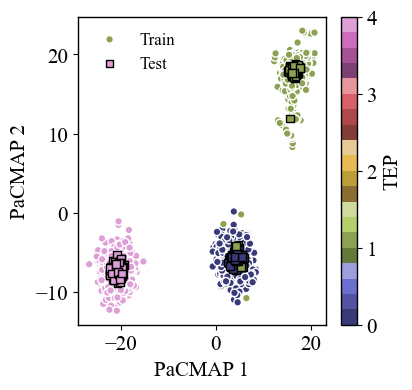

In [13]:
fig, ax = plt.subplots(figsize=(4, 4))
sc = ax.scatter(X_train_reduced[:, 0], X_train_reduced[:, 1], c=y_train, edgecolors='w', cmap='tab20b', s=30)
ax.scatter(X_test_reduced[:, 0], X_test_reduced[:, 1], marker='s', c=y_test, edgecolors='k', cmap='tab20b', s=30, alpha=1)
cbar = plt.colorbar(sc, label='TEP')
cbar.formatter = ticker.FormatStrFormatter('%.0f')
ax.set_xlabel('PaCMAP 1')
ax.set_ylabel('PaCMAP 2')

plt.legend(['Train', 'Test'], loc='best', fontsize=12, frameon=False)

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"
                                ] + plt.rcParams["font.serif"]
plt.rcParams['font.size']=15
plt.rcParams['axes.linewidth'] = 1 

plt.savefig('figures/example-3-1.png', dpi=300, bbox_inches='tight')
plt.show()

# Do clustering on reduced data

## K-means

In [8]:
X_train_reduced_df = pd.DataFrame(X_train_reduced, columns=['PaCMAP_1', 'PaCMAP_2'])

In [9]:
def plot_data(data, centroids=None, title=None, arrows=None):
    """Scatter plot of data with optional centroids and arrows."""
    plt.scatter(
        data.iloc[:, 0], data.iloc[:, 1],
        color=data.get('color', 'k'),
        alpha=0.5, edgecolor='k'
    )
    plt.xlabel('$x_1$ (normalized)')
    plt.ylabel('$x_2$ (normalized)')

    if centroids:
        for i, (x, y) in centroids.items():
            plt.scatter(x, y, cmap='tab20b', s=100, marker='x', label=f'Centroid {i}')

    if arrows:
        ax = plt.axes()
        for i, (old, new) in arrows.items():
            dx = (new[0] - old[0]) * 0.75
            dy = (new[1] - old[1]) * 0.75
            ax.arrow(old[0], old[1], dx, dy,
                     head_width=1, head_length=1,
                     fc='k', ec='k')

    if title:
        plt.title(title)

    plt.show()

In [10]:
def init_centroids(k, seed=1):
    np.random.seed(seed)
    return {
        i + 1: [np.random.randint(0, 10) / 10, np.random.randint(0, 10) / 10]
        for i in range(k)
    }


def assignment(df, centroids):
    COLMAP = {1: 'r', 2: 'g', 3: 'b', 4: 'm', 5: 'c'}
    df = df.copy()
    for i, (cx, cy) in centroids.items():
        df[f'distance_from_{i}'] = np.sqrt(
            (df.iloc[:, 0] - cx) ** 2 + (df.iloc[:, 1] - cy) ** 2
        )

    dist_cols = [f'distance_from_{i}' for i in centroids.keys()]
    df['closest'] = df[dist_cols].idxmin(axis=1)
    df['closest'] = df['closest'].str.replace('distance_from_', '').astype(int)
    df['color'] = df['closest'].map(COLMAP)

    return df


def update_centroids(df, centroids):
    new_centroids = copy.deepcopy(centroids)
    for i in centroids.keys():
        new_centroids[i][0] = np.mean(df[df['closest'] == i].iloc[:, 0])
        new_centroids[i][1] = np.mean(df[df['closest'] == i].iloc[:, 1])
    return new_centroids

/var/folders/q5/6txyk4317txfn_vkvk6sbl9m0000gn/T/ipykernel_35763/955644305.py:13: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(x, y, cmap='tab20b', s=100, marker='x', label=f'Centroid {i}')


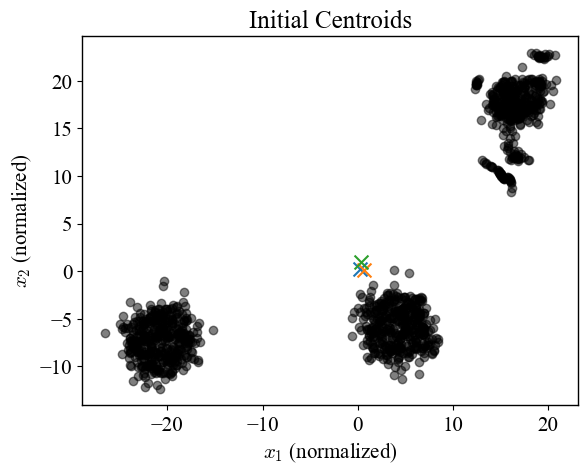

/var/folders/q5/6txyk4317txfn_vkvk6sbl9m0000gn/T/ipykernel_35763/955644305.py:13: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(x, y, cmap='tab20b', s=100, marker='x', label=f'Centroid {i}')


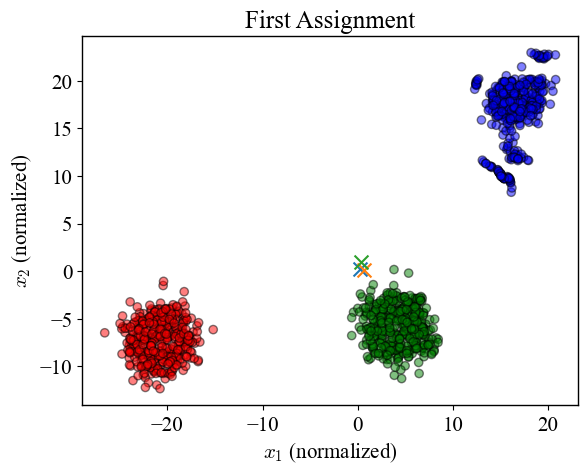

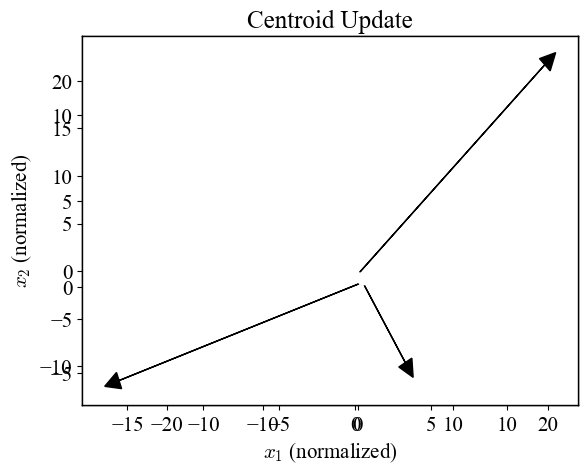

/var/folders/q5/6txyk4317txfn_vkvk6sbl9m0000gn/T/ipykernel_35763/955644305.py:13: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(x, y, cmap='tab20b', s=100, marker='x', label=f'Centroid {i}')


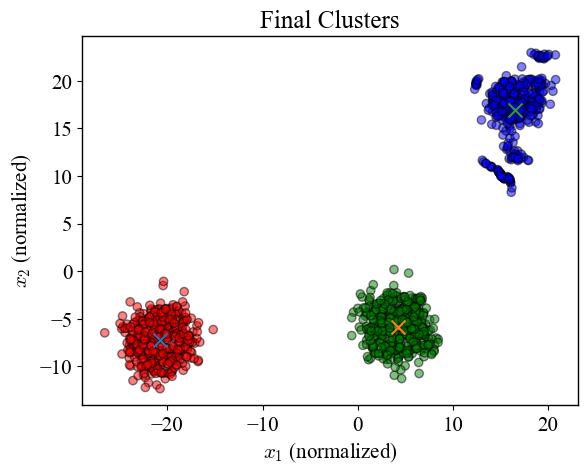

Total SSE: 76905.06


In [11]:
# Initialization
centroids = init_centroids(3, 123)

plot_data(X_train_reduced_df, centroids=centroids, title="Initial Centroids")

# First assignment
data = assignment(X_train_reduced_df, centroids)
plot_data(data, centroids=centroids, title="First Assignment")

# First update
old_centroids = copy.deepcopy(centroids)
centroids = update_centroids(data, centroids)

arrows = {i: (old_centroids[i], centroids[i]) for i in centroids.keys()}
plot_data(data, centroids=centroids, arrows=arrows, title="Centroid Update")

# Repeat until convergence
while True:
    prev_closest = data['closest'].copy()
    centroids = update_centroids(data, centroids)
    data = assignment(data, centroids)
    if prev_closest.equals(data['closest']):
        break

plot_data(data, centroids=centroids, title="Final Clusters")


# Evaluate

errors = {
    i: np.sum(np.sqrt(
        (data.iloc[:, 0] - centroids[i][0]) ** 2 +
        (data.iloc[:, 1] - centroids[i][1]) ** 2
    ))
    for i in centroids.keys()
}

tSSEkmeans = sum(errors.values())
print("Total SSE:", tSSEkmeans)


## HDBSCAN

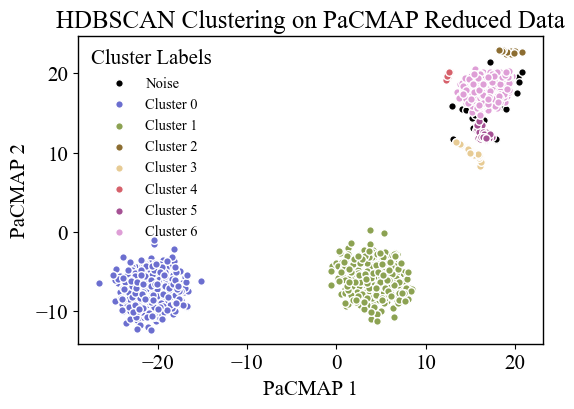

In [12]:
# ignore future warnings
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import hdbscan

# Fit HDBSCAN on the reduced training data
clusterer = hdbscan.HDBSCAN(min_cluster_size=10)
labels = clusterer.fit_predict(X_train_reduced)

plt.figure(figsize=(6, 4))
unique_labels = np.unique(labels)
colors = plt.cm.tab20b(np.linspace(0, 1, len(unique_labels)))

for idx, label in enumerate(unique_labels):
	mask = labels == label
	if label == -1:
		plt.scatter(
			X_train_reduced[mask, 0], X_train_reduced[mask, 1],
			c='k', s=30, edgecolors='w', label='Noise'
		)
	else:
		plt.scatter(
			X_train_reduced[mask, 0], X_train_reduced[mask, 1],
			c=colors[idx].reshape(1, -1), s=30, edgecolors='w', label=f'Cluster {label}'
		)

plt.xlabel('PaCMAP 1')
plt.ylabel('PaCMAP 2')
plt.title('HDBSCAN Clustering on PaCMAP Reduced Data')
plt.legend(frameon=False, title='Cluster Labels', fontsize='x-small')
plt.show()